

## <span style="color:#4375c7">DAI</span>
***
*Course materials are for educational purposes only. Nothing contained herein should be considered investment advice or an opinion regarding the suitability of any security. For more information about this course, please contact us.*
***

### Session contents:
1. **[Deep Learning - Generative models ](#NN)**
    - [Variational autoencoder](#VAE)
    - [Generative adversarial network](#GAN)

    
2. **[Hands-on session](#ho)**
***



<br/><br/>

## 2. Hands-on session <a id='ho'></a>

### Exercise 1
1. Read the day-ahead electricity data set and visualize a random set of daily auctions. Each auction contains 24 load auction prices, one for each hour of the day. Fill in the missing parts of the code marked with ___. 

2. Use the given structure of a GAN to generate new time series. Fill in the missing parts of the code marked with ___. Use dense layers instead of convolutional layers. Execute the code and generate new time series.


### Exercise 2
1.  Read the day-ahead electricity dataset and split the dataset into a test dataset and a train dataset. Do a split after four years of data. Keep leap years in mind. 

2. Use the given structure of a VAE to generate new time series. Fill in the missing parts of the code marked with ___. Use dense layers instead of convolutional layers. Execute the code and generate new time series.


### Solution exercise 1

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
# Ensure working directory is repo root (data/ lives there)
if os.path.basename(os.getcwd()) == "exercises":
    os.chdir("..")
elif not os.path.exists("data/Dataset_dayahead.csv"):
    # On Colab: clone repo
    os.system("git clone https://github.com/firrm/DAI.git")
    os.chdir("DAI")
print("Working dir:", os.getcwd())


Working dir: /home/pnp/10FiRRM/02_teaching/003_lecture/DAI_Msc/000_repo/DAI


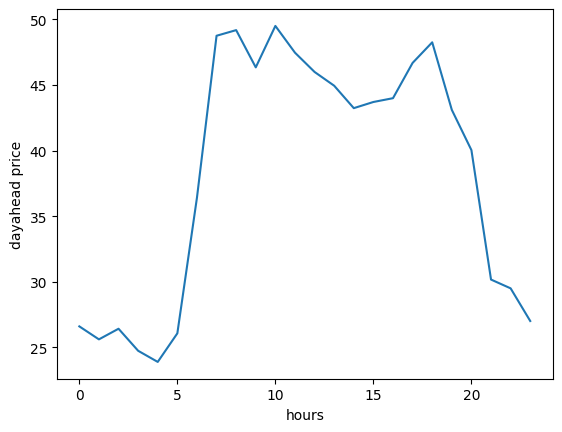

In [2]:
#1)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#read in the data and plot a random set
x_train = pd.DataFrame(pd.read_csv("data/Dataset_dayahead.csv")[1:]).values

plt.plot(x_train[np.random.randint(1,1000)])
plt.xlabel("hours")
plt.ylabel("dayahead price")
plt.show()


In [3]:
#2)
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras import layers
from keras.models import Model
import matplotlib.pyplot as plt
from tqdm import tqdm

latent_dim = 24
iterations = 200  # increase to 10000 for better results (e.g. on GPU)
batch_size = 100

shapes = pd.read_csv("data/Dataset_dayahead.csv")
x_train = np.array(shapes).astype(np.float32)

generator_input = keras.Input(shape=(latent_dim, ))
x = layers.Dense(24)(generator_input)
x = layers.LeakyReLU(0.3)(x)
x = layers.Dense(128)(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Dense(256)(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Dense(24, activation="tanh")(x)
generator = keras.models.Model(generator_input, x)
generator.summary()


I0000 00:00:1776103857.097849  564194 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776103857.144170  564194 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1776103858.236424  564194 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1776103858.791075  564194 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776103858.791348  564278 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776103858.824750  564194 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,992 (167.94 KB)

 Trainable params: 42,992 (167.94 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
discriminator_input = layers.Input(shape=(latent_dim, ))
x = layers.Dense(256)(discriminator_input)
x = layers.LeakyReLU(0.3)(x)
x = layers.Dense(128)(x)
x = layers.LeakyReLU(0.3)(x)
x = layers.Dropout(0.3)(x)
discriminator_output = layers.Dense(1, activation="sigmoid")(x)
discriminator = keras.models.Model(discriminator_input, discriminator_output)
discriminator.summary()

discriminator_optimizer = keras.optimizers.RMSprop(learning_rate=0.0004, clipvalue=1.0, decay=1e-8)
discriminator.compile(optimizer=discriminator_optimizer, loss="binary_crossentropy")


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,425 (154.00 KB)

 Trainable params: 39,425 (154.00 KB)

 Non-trainable params: 0 (0.00 B)

/home/pnp/10FiRRM/02_teaching/003_lecture/DAI_Msc/000_repo/DAI/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [5]:
discriminator.trainable = False
gan_input = keras.Input(shape=(latent_dim, ))
gan_output = discriminator(generator(gan_input))
gan = keras.models.Model(gan_input, gan_output)

gan_optimizer = keras.optimizers.RMSprop(learning_rate=0.004, clipvalue=1.0, decay=1e-8)
gan.compile(optimizer=gan_optimizer, loss="binary_crossentropy")


In [6]:
loss_a, loss_d = [], []
start = 0

for step in tqdm(range(iterations)):
    random_latent_vectors = np.random.normal(size=(batch_size, latent_dim))
    generated_ts = generator.predict(random_latent_vectors, verbose=0)
    stop = start + batch_size
    real_ts = x_train[start:stop]
    combined_ts = np.concatenate([generated_ts, real_ts])
    labels = np.concatenate([np.ones((batch_size, 1)), np.zeros((batch_size, 1))])
    labels += 0.05 * np.random.random(labels.shape)
    discriminator.trainable = True
    d_loss = discriminator.train_on_batch(combined_ts, labels)
    random_latent_vector = np.random.normal(size=(batch_size, latent_dim))
    misleading_targets = np.zeros((batch_size, 1))
    discriminator.trainable = False
    a_loss = gan.train_on_batch(random_latent_vectors, misleading_targets)
    start += batch_size
    if start > len(x_train) - batch_size:
        start = 0
    if step % 10 == 0:
        print(f"discriminator loss at step {step}: {d_loss}")
        print(f"adversarial loss at step {step}: {a_loss}")
        loss_a.append(a_loss)
        loss_d.append(d_loss)


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 1/200 [00:00<02:26,  1.36it/s]

  2%|▏         | 4/200 [00:00<00:34,  5.72it/s]

discriminator loss at step 0: 8.991277694702148
adversarial loss at step 0: 0.710643470287323


  4%|▎         | 7/200 [00:01<00:20,  9.44it/s]

...

 96%|█████████▋| 193/200 [00:08<00:00, 23.32it/s]

discriminator loss at step 190: 0.5015496015548706
adversarial loss at step 190: 0.91797935962677


 98%|█████████▊| 196/200 [00:08<00:00, 23.16it/s]

100%|█████████▉| 199/200 [00:08<00:00, 23.24it/s]

100%|██████████| 200/200 [00:08<00:00, 22.37it/s]

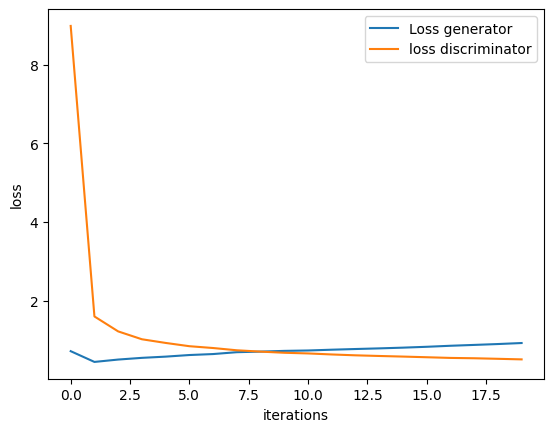

In [7]:
plt.plot(loss_a, label="Loss generator")
plt.plot(loss_d, label="loss discriminator")
plt.legend()
plt.ylabel("loss")
plt.xlabel("iterations")
plt.show()


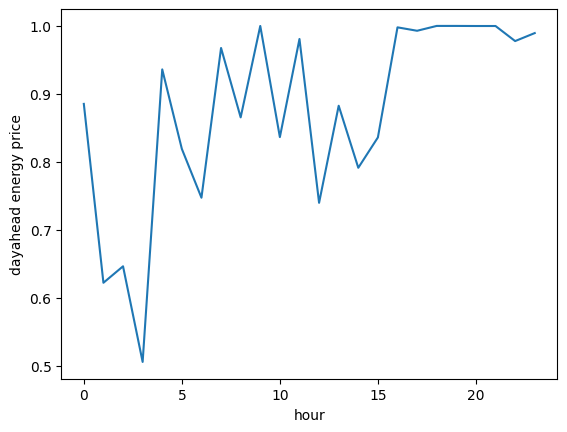

In [8]:
random_latent_vectors = np.random.normal(size=(1, latent_dim))
gen_ts = generator.predict(random_latent_vectors, verbose=0)
plt.plot(pd.DataFrame(gen_ts).T)
plt.xlabel("hour")
plt.ylabel("dayahead energy price")
plt.show()


### Solution exercise 2

In [9]:
#1)
import pandas as pd
import numpy as np
import keras
from keras import layers
from keras import backend as K
from keras.models import Model
import tensorflow as tf
import matplotlib.pyplot as plt

shapes = pd.read_csv("data/Dataset_dayahead.csv")

x_train = np.array(shapes.iloc[0:365 * 5 + 0, :]).astype(np.float32)
x_test = np.array(shapes.iloc[365 * 5 - 1:365 * 6]).astype(np.float32)


In [10]:
#2)
input_shape = (x_train.shape[1], )
latent_dim = 8
batch_size = 16
epochs = 2  # increase to 50 for better results (e.g. on GPU)

inputs = keras.Input(shape=input_shape)
x = layers.Dense(128, activation="relu")(inputs)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim), mean=0., stddev=1.0)
    return z_mean + keras.ops.exp(z_log_var) * epsilon

z = layers.Lambda(sampling, output_shape=(latent_dim,))([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

decoder_input = layers.Input(shape=(latent_dim,))
x = layers.Dense(32, activation="relu")(decoder_input)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(input_shape[0], activation="linear")(x)

decoder = Model(decoder_input, x, name="decoder")
z_decoded = decoder(z)


In [11]:
# Custom VAE model
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(tf.reduce_mean(kl_loss) / tf.cast(tf.shape(inputs)[0], tf.float32))
        return reconstructed

vae = VAE(encoder, decoder)
vae.compile(optimizer='rmsprop', loss='mse')

In [12]:
# Train the VAE
vae.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, validation_data=(x_test, x_test))

Epoch 1/2


  1/115 ━━━━━━━━━━━━━━━━━━━━ 1:25 752ms/step - loss: 957665374917777986320072704.0000

 60/115 ━━━━━━━━━━━━━━━━━━━━ 0s 851us/step - loss: nan                               

115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: nan - val_loss: nan


Epoch 2/2


  1/115 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: nan

 66/115 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - loss: nan

115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: nan - val_loss: nan


### References
***
[1] Keras online documentation: https://keras.io/about/

[2] Rashid, T. (2017). Neuronale Netze selbst programmieren: ein verständlicher Einstieg mit Python. O'Reilly.

[3] Nguyen, C. N., & Zeigermann, O. (2018). Machine Learning: kurz & gut.

[4] Chollet, F. (2018). Deep Learning mit Python und Keras: Das Praxis-Handbuch vom Entwickler der Keras-Bibliothek. MITP-Verlags GmbH & Co. KG. Code available on: https://github.com/fchollet/deep-learning-with-python-notebooks

[5]  Jason Brownlee (2019). https://machinelearningmastery.com/impressive-applications-of-generative-adversarial-networks/

[6] Kingma, D. P., & Welling, M. (2013). Auto-encoding variational bayes. arXiv preprint arXiv:1312.6114.

[7] Rezende, D. J., Mohamed, S., & Wierstra, D. (2014). Stochastic backpropagation and approximate inference in deep generative models. arXiv preprint arXiv:1401.4082.

[8] Goodfellow, I., Pouget-Abadie, J., Mirza, M., Xu, B., Warde-Farley, D., Ozair, S., Courville, A. & Bengio, Y. (2014). Generative adversarial nets. In Advances in neural information processing systems (pp. 2672-2680).